In [1]:
import numpy as np
from scipy import fft, stats
import matplotlib.pyplot as plt

 - https://stackoverflow.com/questions/79701003/generating-blue-noise-with-values-sampled-from-a-log-normal-distribution?noredirect=1#comment140588658_79701003
 - https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python/67127726#67127726

In [24]:
def plot(s, color=None, label=None, axe=None):
    if axe is None:
        fig, axe = plt.subplots()
    f = fft.rfftfreq(len(s))
    axe.loglog(f, np.abs(fft.rfft(s)), color=color, label=label)
    return axe 

In [3]:
def noise(size, power=lambda f: 1., distribution=stats.norm):
    X = fft.rfft(distribution.rvs(size=size))
    S = power(fft.rfftfreq(size))
    S /= np.sqrt(np.mean(S ** 2))
    X *= S
    return fft.irfft(X)

In [31]:
distributions = {
    "Normal": stats.norm(),
    "Log Normal": stats.lognorm(s=0.3),
    "Beta": stats.beta(a=0.5, b=2),
    "Gamma": stats.gamma(a=0.5)
}

In [32]:
powers = {
    "White": lambda f: 1.,
    "Blue": lambda f: np.sqrt(f),
    "Violet": lambda f: f,
    "Brown": lambda f: 1. / np.where(f == 0, float('inf'), f),
    "Pink": lambda f: 1. / np.where(f == 0, float('inf'), np.sqrt(f))
}

In [33]:
colors = ["gray", "blue", "violet", "brown", "pink"] 

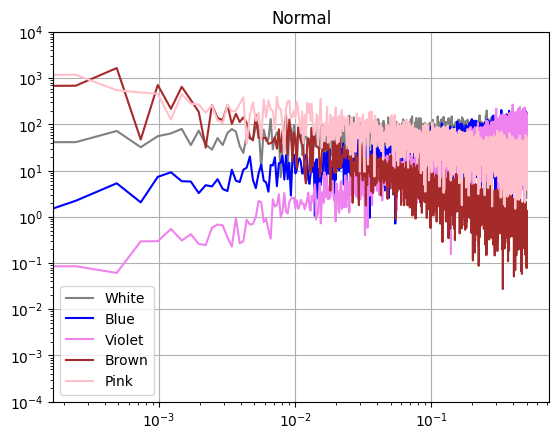

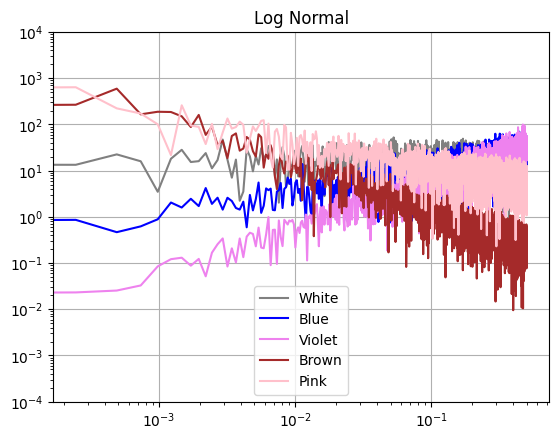

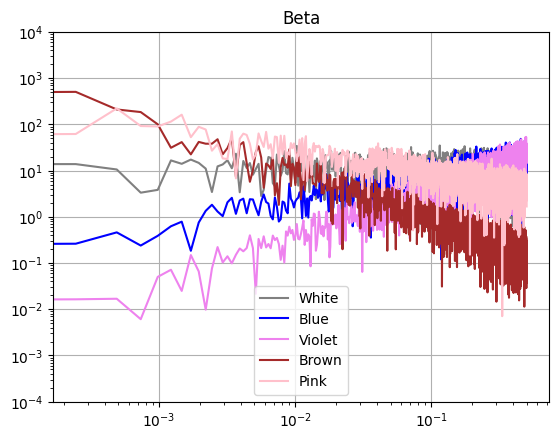

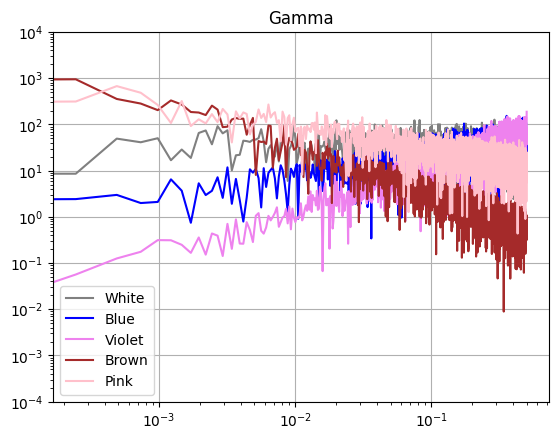

In [34]:
size = 4096
for dkey, distribution in distributions.items():
    fig, axe = plt.subplots()
    for ((pkey, power), color) in zip(powers.items(), colors):
        s = noise(size, power=power, distribution=distribution)
        plot(s, label=pkey, color=color, axe=axe)
    axe.set_ylim([1e-4, 1e4])
    axe.set_title(dkey)
    axe.legend()
    axe.grid()